# 02 — Oracle Experiment

**Experiment B04 (WBS T016).** The single most important measurement in the whole plan: feed gold evidence directly to the model (bypassing retrieval entirely) to answer *is the reasoning ceiling set by retrieval quality, or by the model itself?*

The actual API calls were made by `scripts/run_oracle_experiment.py` — this notebook does **not** repeat them (no reason to re-spend real money). It loads the already-saved result (`results/runs/run_B04_oracle_openai_gpt-5-mini.jsonl`) and reconstructs the exact same 150-case sample from the same seed (deterministic, no API calls) so it can cross-reference predictions against gold labels for the chart and the error analysis below.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "scripts"))

from pipeline.viz_style import CATEGORICAL, apply_style, style_axes, savefig_kwargs
from evaluation.harness import EvaluationHarness
from pipeline.parser import parse_contractnli_file
from pipeline.config import settings
from run_oracle_experiment import stratified_sample, SEED

apply_style()

harness = EvaluationHarness()
results = harness.load_results("runs/run_B04_oracle_openai_gpt-5-mini.jsonl")
result = results[0]
print(f"Loaded run: {result.config.experiment_id}, model={result.config.model}, "
      f"{len(result.predictions)} predictions, timestamp={result.timestamp}")

Loaded run: B04_oracle, model=openai/gpt-5-mini, 150 predictions, timestamp=2026-09-22T10:46:49.898863+00:00


In [2]:
# Reconstruct the exact same sample (same seed -> same cases, no API calls)
# so we have gold labels to cross-reference against the saved predictions.
dataset = parse_contractnli_file(settings.data_path / "dev.json")
sample = stratified_sample(dataset, len(result.predictions), SEED)
gold_by_key = {(doc.doc_id, ann.hypothesis_id): ann.label for doc, ann in sample}

pred_by_key = {(p.doc_id, p.hypothesis_id): p for p in result.predictions}
assert set(gold_by_key) == set(pred_by_key), "reconstructed sample doesn't match saved predictions - seed or sample size mismatch"
print(f"Cross-referenced {len(gold_by_key)} cases successfully")

Cross-referenced 150 cases successfully


## Metrics

For this experiment, `retrieved_span_indices` is set equal to `gold_span_indices` by construction (the model was handed exactly the gold evidence) — evidence metrics are trivially perfect, so joint correctness collapses to label accuracy, exactly as the planning doc expects for Oracle.

In [3]:
m = result.metrics
print(f"Accuracy:              {m.accuracy:.3f}")
print(f"Macro-F1:               {m.macro_f1:.3f}")
print(f"Risk-sensitive recall:  {m.risk_sensitive_recall:.3f}")
print(f"Joint correctness:      {m.joint_label_evidence_correctness:.3f}")
print(f"Total cost:             ${m.total_cost_usd:.4f}")
print(f"p50 latency:            {m.p50_latency_ms:.0f}ms")
print()
for label, pc in m.per_class.items():
    print(f"  {label:14} precision={pc['precision']:.3f} recall={pc['recall']:.3f} f1={pc['f1']:.3f}")

Accuracy:              0.967
Macro-F1:               0.951
Risk-sensitive recall:  1.000
Joint correctness:      0.967
Total cost:             $0.1549
p50 latency:            5769ms

  Entailment     precision=1.000 recall=0.933 f1=0.966
  Contradiction  precision=0.824 recall=1.000 f1=0.903
  NotMentioned   precision=0.968 recall=1.000 f1=0.984


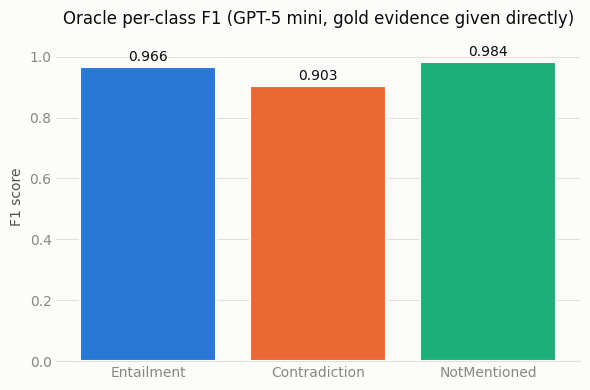

In [4]:
labels = ["Entailment", "Contradiction", "NotMentioned"]

fig, ax = plt.subplots(figsize=(6, 4))
f1_scores = [m.per_class[l]["f1"] for l in labels]
bars = ax.bar(labels, f1_scores, color=[CATEGORICAL[l] for l in labels],
              edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.02, f"{score:.3f}",
            ha="center", fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel("F1 score")
ax.set_title("Oracle per-class F1 (GPT-5 mini, gold evidence given directly)")
style_axes(ax)
plt.tight_layout()
plt.savefig("results/comparisons/oracle_per_class_f1.png", **savefig_kwargs())
plt.show()

## Error Analysis

Only 5 of 150 cases were wrong. All 5 go the same direction.

In [5]:
errors = [(key, gold_by_key[key], pred_by_key[key]) for key in gold_by_key
          if gold_by_key[key] != pred_by_key[key].predicted_label.value]

print(f"{len(errors)} errors out of {len(gold_by_key)} cases\n")
for (doc_id, hyp_id), gold, pred in errors:
    print(f"{doc_id}/{hyp_id}: gold={gold} pred={pred.predicted_label.value} (confidence={pred.confidence:.2f})")
    print(f"  explanation: {pred.explanation[:200]}")
    print()

5 errors out of 150 cases

482/nda-15: gold=Entailment pred=NotMentioned (confidence=0.85)
  explanation: The provided clause only refers to not granting rights to "any invention, discovery or improvement" and does not state that the Agreement shall not grant the Receiving Party rights to "Confidential In

63/nda-4: gold=Entailment pred=Contradiction (confidence=0.90)
  explanation: Although the NDA requires use only for the expressly stated purpose, it expressly carves out an exception allowing parties to continue ordinary-course business (including dealings with the other's cus

590/nda-15: gold=Entailment pred=Contradiction (confidence=0.90)
  explanation: The NDA expressly carves out an exception granting the Receiving Party a "limited right to use" Proprietary Information, so it does grant at least some rights and therefore contradicts the requirement

27/nda-1: gold=Entailment pred=Contradiction (confidence=0.90)
  explanation: The NDA definition includes information "designated 

**Finding:** every error is gold=Entailment predicted as something else (Contradiction or NotMentioned) — the model never once over-claimed Entailment when it shouldn't have. It caught **100% of the 14 real Contradictions** and **100% of the 61 real NotMentioned cases** in this sample. For a legal-review tool, this is the safer failure mode: under-claiming a protection is a false negative a human reviewer can catch by re-reading a flagged case; over-claiming one (missing a real contradiction) is the dangerous silent failure the risk-sensitive recall metric exists to catch.

## Decision Gate (Section 10, Oracle Decision Tree)

| Threshold | This result | Verdict |
|---|---|---|
| < 75% | 96.7% | model too weak — N/A |
| > 90% | 96.7% | **model reasons well — retrieval is the bottleneck** |

**Decision: proceed to retrieval work.** The model is not the constraint. (A follow-up model bake-off, Experiment C01, then asked a *different* question — not "is this model good enough" but "is this the best value for money" — see `03_model_comparison.ipynb`.)